<a href="https://colab.research.google.com/github/Cayzoxs/UAS-TA-Machine-Learning/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Mengimpor Library dan Memuat Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

url = "https://raw.githubusercontent.com/Cayzoxs/UAS-TA-Machine-Learning/main/data/raw/data.csv"
df = pd.read_csv(url, sep=';')

# Menampilkan 5 baris pertama untuk memastikan data terbaca
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# 2. Pembersihan Data (Data Cleaning)

In [ ]:
print("--- INFO DATASET ---")
df.info()

print("\n--- CEK MISSING VALUES ---")
print(df.isnull().sum().sum(), "Missing Values Ditemukan")

print("\n--- CEK DUPLIKAT ---")
print(df.duplicated().sum(), "Baris Duplikat Ditemukan")

df = df[df['Target'] != 'Enrolled']
print("\nDimensi data setelah menghapus 'Enrolled':", df.shape)

--- INFO DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualificati

# 3. Melakukan Exploratory Data Analysis (EDA)

/tmp/ipykernel_473/3928883657.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Target', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_473/3928883657.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Target', y='Age at enrollment', ax=axes[0, 1], palette='Set2')


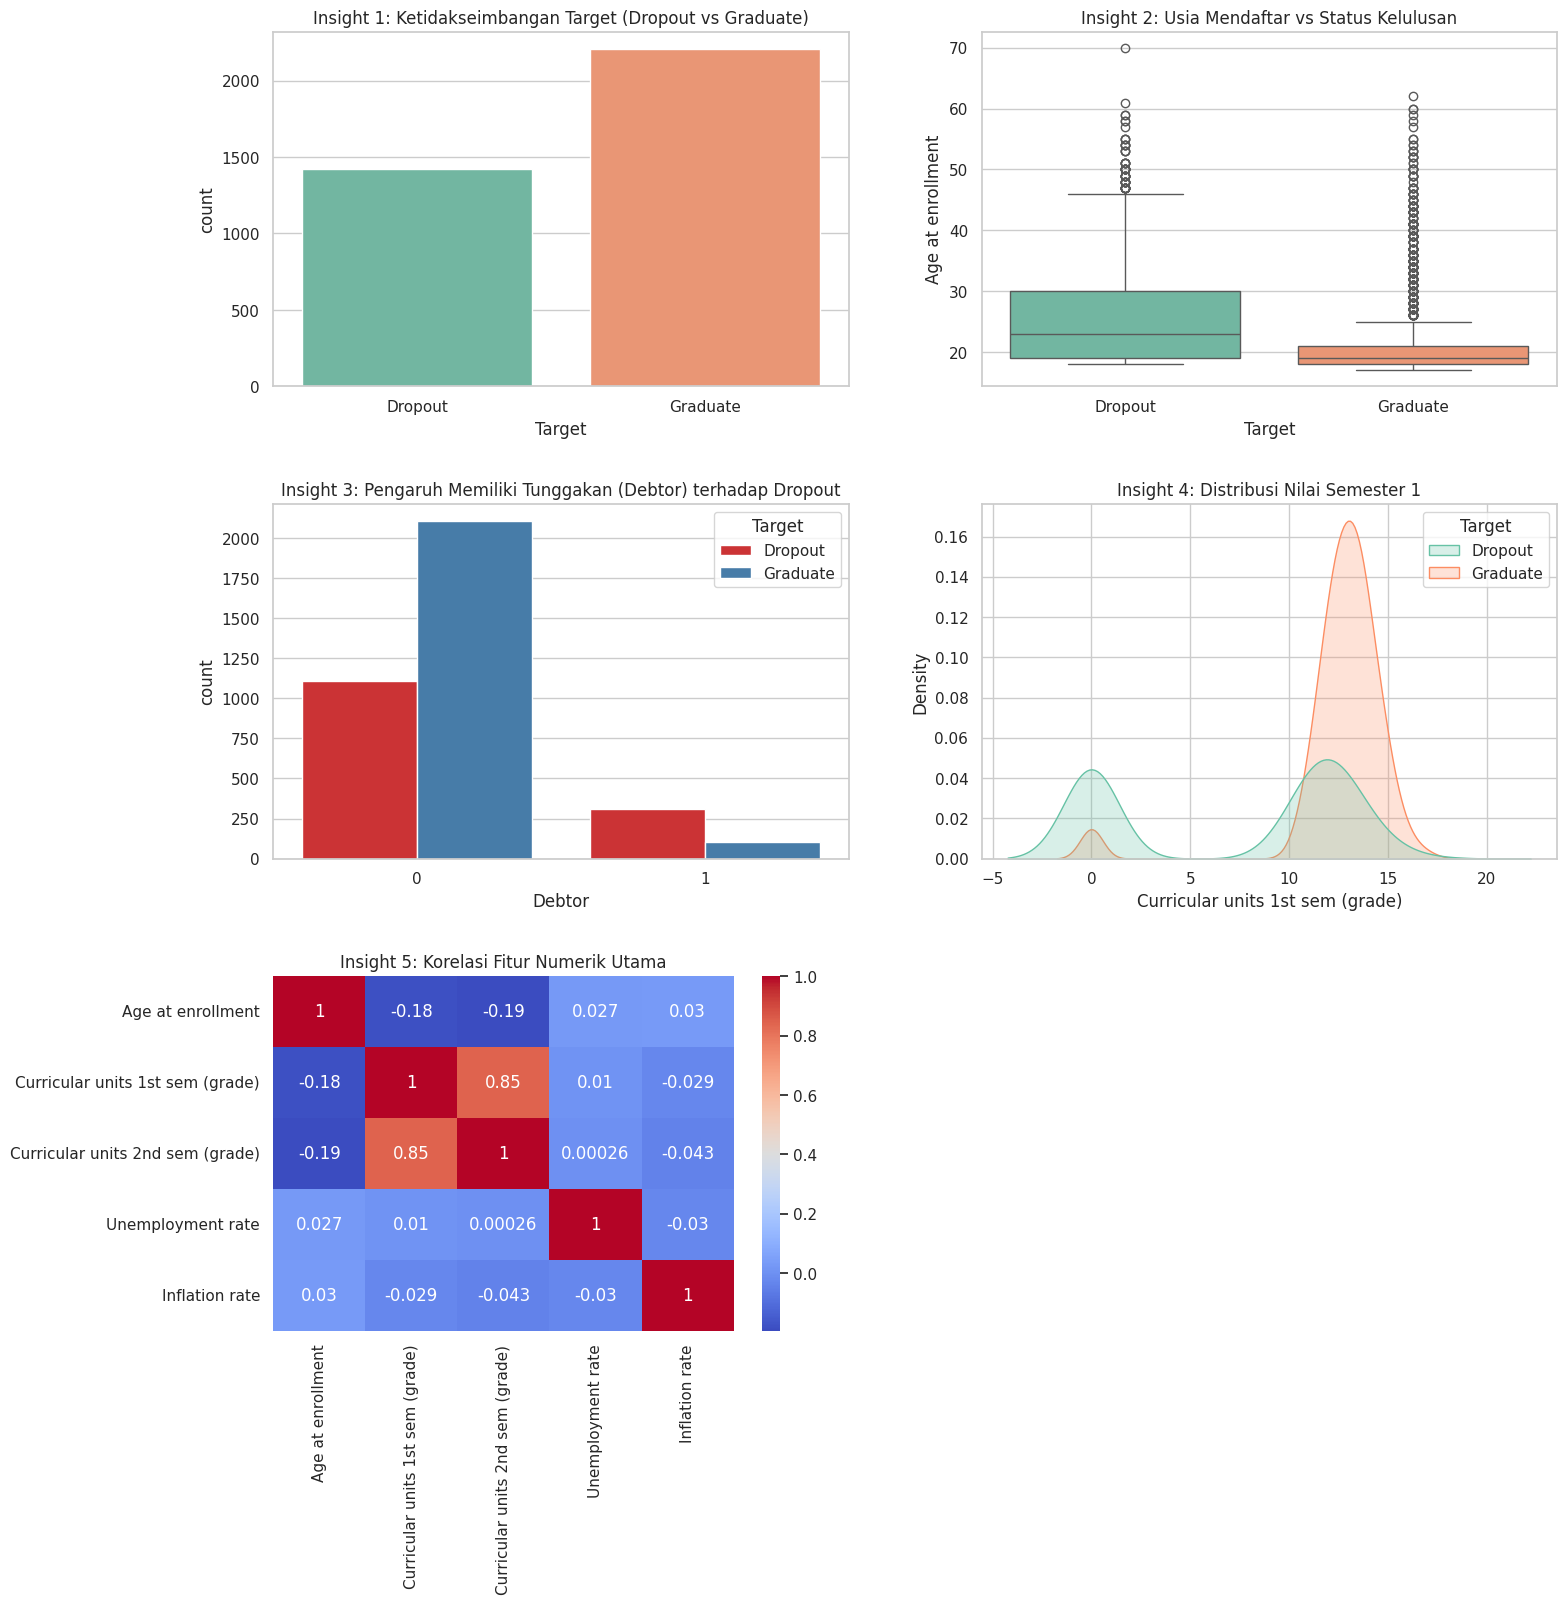

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.tight_layout(pad=5.0)

# Insight 1: Distribusi Kelas Target (Membuktikan Imbalanced Data)
sns.countplot(data=df, x='Target', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Insight 1: Ketidakseimbangan Target (Dropout vs Graduate)')

# Insight 2: Pengaruh Umur saat Mendaftar terhadap Dropout
sns.boxplot(data=df, x='Target', y='Age at enrollment', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Insight 2: Usia Mendaftar vs Status Kelulusan')

# Insight 3: Status Hutang / Debtor
sns.countplot(data=df, x='Debtor', hue='Target', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Insight 3: Pengaruh Memiliki Tunggakan (Debtor) terhadap Dropout')

# Insight 4: IPK Semester 1 (Curricular units 1st sem (grade))
sns.kdeplot(data=df, x='Curricular units 1st sem (grade)', hue='Target', fill=True, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Insight 4: Distribusi Nilai Semester 1')

# Insight 5: Korelasi antar beberapa fitur numerik utama
fitur_numerik = ['Age at enrollment', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)', 'Unemployment rate', 'Inflation rate']
sns.heatmap(df[fitur_numerik].corr(), annot=True, cmap='coolwarm', ax=axes[2, 0])
axes[2, 0].set_title('Insight 5: Korelasi Fitur Numerik Utama')

fig.delaxes(axes[2,1]) # Menghapus plot ke-6 yang kosong
plt.show()

# 4. Praproccessing Data

In [ ]:
# 1. Memisahkan Fitur (X) dan Target (y)
X = df.drop('Target', axis=1)
y = df['Target']

# 2. Encoding Target (Dropout = 1, Graduate = 0)
le = LabelEncoder()
y = le.fit_transform(y)

# 3. Scaling Fitur (Standarisasi agar skala angka seragam)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 4. Train-Test Split (80% Latih, 20% Uji)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Proses Preprocessing Selesai!")
print(f"Jumlah Data Latih: {X_train.shape[0]}")
print(f"Jumlah Data Uji: {X_test.shape[0]}")

Proses Preprocessing Selesai!
Jumlah Data Latih: 2904
Jumlah Data Uji: 726
